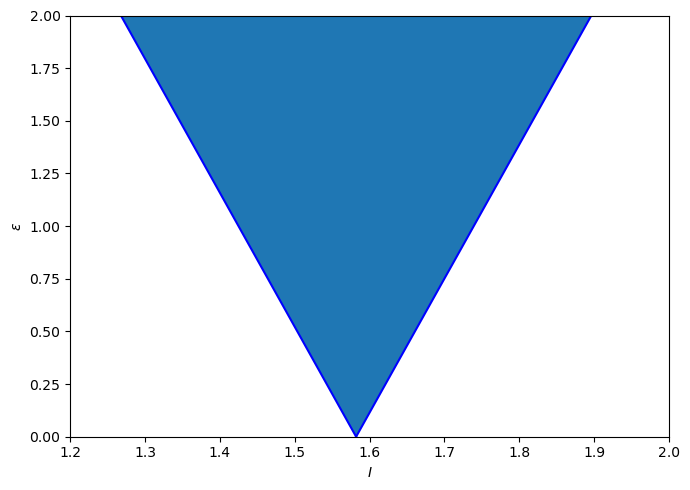

In [4]:
import numpy as np
import matplotlib.pyplot as plt

I_star = 1 / (1 - np.exp(-1))
epsilon = np.linspace(0, 2, 500)

left = I_star - epsilon / np.sqrt(1 + 4 * np.pi**2)
right = I_star + epsilon / np.sqrt(1 + 4 * np.pi**2)

fig, ax = plt.subplots(figsize=(7, 5))

ax.fill_betweenx(epsilon, left, right)
ax.plot(left, epsilon, color="blue")
ax.plot(right, epsilon, color="blue")

ax.set_xlim(1.2, 2.0)
ax.set_ylim(0, 2.0)
ax.set_xlabel(r"$I$")
ax.set_ylabel(r"$\epsilon$")

plt.tight_layout()
plt.show()

1.5034, 1.6606

last 10 spike phases at I = 1.6:
[0.188052 0.188052 0.188052 0.188052 0.188052 0.188052 0.188052 0.188052
 0.188052 0.188052]


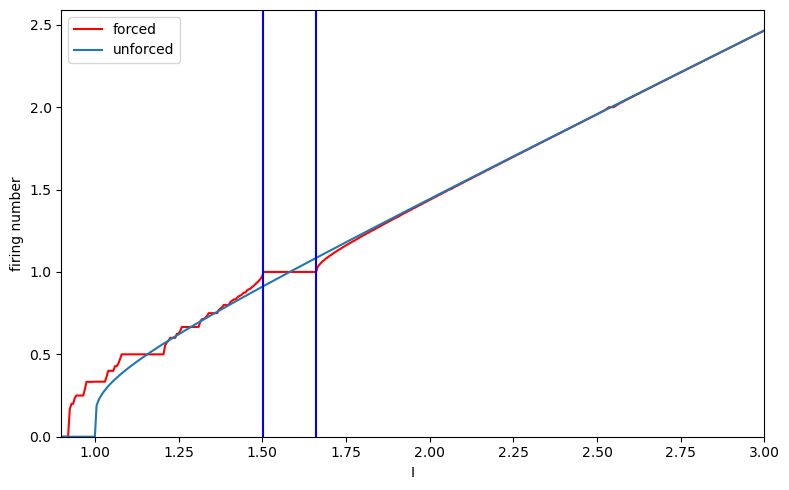

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

eps = 0.5
trans = 500.0
t_m = 1000.0
t_end = trans + t_m

step = 0.02

I_star = 1 / (1 - np.exp(-1))
K = 1 / np.sqrt(1 + 4 * np.pi**2)

IL = I_star - eps * K
IR = I_star + eps * K


def G(t, I):
    return (
        I
        + eps
        * (
            np.sin(2 * np.pi * t)
            - 2 * np.pi * np.cos(2 * np.pi * t)
        )
        / (1 + 4 * np.pi**2)
    )


def FindNextStep(t_r, I, t_s):
    if I + eps * K <= 1:
        return np.inf

    G_reset = G(t_r, I)

    def difference(t):
        voltage = (
            G(t, I)
            - G_reset * np.exp(-(t - t_r))
        )
        return voltage - 1

    left = t_r

    while left < t_s:
        times = left + step * np.arange(1, 101)
        times = times[times < t_s]

        if len(times) == 0:
            times = np.array([t_s])
        elif times[-1] + step >= t_s:
            times = np.append(times, t_s)

        values = difference(times)
        hits = np.flatnonzero(values >= 0)

        if len(hits) > 0:
            j = hits[0]

            a = left if j == 0 else times[j - 1]
            b = times[j]

            return brentq(difference, a, b, xtol=1e-12)

        left = times[-1]

    return np.inf


def sim(I, t_s=None):
    if t_s is None:
        t_s = t_end

    spikeTimes = []
    t_r = 0.0

    while t_r < t_s:
        spike_time = FindNextStep(t_r, I, t_s)

        if not np.isfinite(spike_time):
            break

        spikeTimes.append(spike_time)
        t_r = spike_time

    return np.array(spikeTimes)


currents = np.unique(
    np.concatenate([
        np.linspace(0.9, 3.0, 421),
        [IL, IR]
    ])
)

forced_rates = []

for index, I in enumerate(currents):
    spikes = sim(I)

    numSpikes = np.count_nonzero(
        (spikes > trans) & (spikes <= t_end)
    )

    numFire = numSpikes / t_m
    forced_rates.append(numFire)


forced_rates = np.array(forced_rates)

unforced_rates = np.zeros_like(currents)
above_threshold = currents > 1

unforced_rates[above_threshold] = (
    1 / np.log(
        currents[above_threshold]
        / (currents[above_threshold] - 1)
    )
)


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    currents,
    forced_rates,
    color="r",
    label=r"forced"
)

ax.plot(
    currents,
    unforced_rates,
    label="unforced"
)

ax.axvline(IL,color="b", linestyle="-")
ax.axvline(IR,color="b", linestyle="-")

ax.set_xlabel("I")
ax.set_ylabel("firing number")
ax.set_xlim(0.9, 3.0)
ax.set_ylim(bottom=0)

ax.legend()
plt.tight_layout()

spikes = sim(1.6)
late_spikes = spikes[spikes > trans]
phases = late_spikes % 1

print(f"{IL:.4f}, {IR:.4f}")

print("\nlast 10 spike phases at I = 1.6:")
print(np.round(phases[-10:], 6))
plt.show()


LIF period: 1.0986
FHN period: 39.4744
FHN min: R = -0.1181, phase = 0.3070
FHN max: R = 0.2849, phase = 0.8922
R < 0:
0.2200 < phase < 0.7985


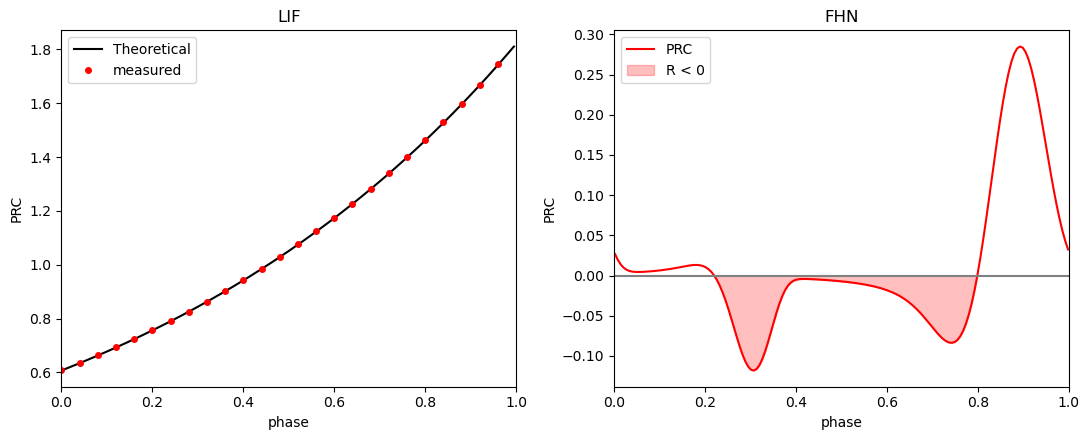

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

tau = 1.0
I = 1.5
v_reset = 0.0
v_threshold = 1.0
delta = 1e-3

v_equilibrium = I * tau

period_LIF = tau * np.log(
    (v_equilibrium - v_reset)
    / (v_equilibrium - v_threshold)
)

phi_LIF = np.linspace(0.0, 0.995, 200)
R_LIF_measured = []

for phi in phi_LIF:
    t_kick = phi * period_LIF

    v_before = (
        v_equilibrium
        + (v_reset - v_equilibrium)
        * np.exp(-t_kick / tau)
    )

    v_after = v_before + delta

    if v_after >= v_threshold:
        t_spike = t_kick
    else:
        time_remaining = tau * np.log(
            (v_equilibrium - v_after)
            / (v_equilibrium - v_threshold)
        )
        t_spike = t_kick + time_remaining

    R = (
        (period_LIF - t_spike)
        / (period_LIF * delta)
    )

    R_LIF_measured.append(R)

R_LIF_measured = np.array(R_LIF_measured)

R_LIF_formula = (
    tau
    * np.exp(phi_LIF * period_LIF / tau)
    / (
        period_LIF
        * (v_equilibrium - v_reset)
    )
)


def FHN(t, state):
    v, w = state
    dv = v - v**3 / 3.0 - w + 0.5
    dw = 0.08 * (v + 0.7 - 0.8 * w)
    return [dv, dw]


def spike_event(t, state):
    return state[0]


spike_event.direction = 1
spike_event.terminal = False

settled = solve_ivp(
    FHN,
    (0.0, 900.0),
    [-1.0, 1.0],
    events=spike_event,
    rtol=1e-10,
    atol=1e-12,
    max_step=0.1
)

if not settled.success:
    raise RuntimeError(settled.message)

spike_times = settled.t_events[0]
spike_states = settled.y_events[0]

if len(spike_times) < 3:
    raise RuntimeError("Too few spikes detected.")

period_FHN = spike_times[-1] - spike_times[-2]
phase_zero_state = spike_states[-1].copy()

orbit = solve_ivp(
    FHN,
    (0.0, period_FHN),
    phase_zero_state,
    dense_output=True,
    rtol=1e-10,
    atol=1e-12,
    max_step=0.1
)

if not orbit.success:
    raise RuntimeError(orbit.message)


def measure_FHN_PRC(phi, kick=delta, cycles=5):
    t_kick = phi * period_FHN
    perturbed_state = orbit.sol(t_kick).copy()
    perturbed_state[0] += kick

    solution = solve_ivp(
        FHN,
        (t_kick, (cycles + 1.2) * period_FHN),
        perturbed_state,
        events=spike_event,
        rtol=1e-9,
        atol=1e-11,
        max_step=0.1
    )

    if not solution.success:
        raise RuntimeError(solution.message)

    perturbed_spikes = solution.t_events[0]

    if len(perturbed_spikes) == 0:
        raise RuntimeError(
            f"No spikes detected at phase {phi:.4f}."
        )

    reference_time = cycles * period_FHN

    index = np.argmin(
        np.abs(perturbed_spikes - reference_time)
    )

    perturbed_time = perturbed_spikes[index]

    return (
        (reference_time - perturbed_time)
        / (period_FHN * kick)
    )


phi_FHN = np.linspace(0.002, 0.998, 161)
R_FHN = np.empty_like(phi_FHN)

for j, phi in enumerate(phi_FHN):
    R_FHN[j] = measure_FHN_PRC(phi)

zero_phases = []

for j in range(len(phi_FHN) - 1):
    if R_FHN[j] == 0:
        zero_phases.append(phi_FHN[j])
    elif R_FHN[j] * R_FHN[j + 1] < 0:
        root = brentq(
            measure_FHN_PRC,
            phi_FHN[j],
            phi_FHN[j + 1],
            xtol=1e-8
        )
        zero_phases.append(root)

if R_FHN[-1] == 0:
    zero_phases.append(phi_FHN[-1])

boundaries = sorted(set(
    [phi_FHN[0]] + zero_phases + [phi_FHN[-1]]
))

negative_intervals = []

for left, right in zip(boundaries[:-1], boundaries[1:]):
    midpoint = (left + right) / 2

    if measure_FHN_PRC(midpoint) < 0:
        negative_intervals.append((left, right))

print(f"\nLIF period: {period_LIF:.4f}")
print(f"FHN period: {period_FHN:.4f}")

j_min = np.argmin(R_FHN)
j_max = np.argmax(R_FHN)

print(
    f"FHN min: R = {R_FHN[j_min]:.4f}, "
    f"phase = {phi_FHN[j_min]:.4f}"
)

print(
    f"FHN max: R = {R_FHN[j_max]:.4f}, "
    f"phase = {phi_FHN[j_max]:.4f}"
)

print("R < 0:")

if negative_intervals:
    for left, right in negative_intervals:
        print(f"{left:.4f} < phase < {right:.4f}")
else:
    print("None detected.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(
    phi_LIF,
    R_LIF_formula,
    color="black",
    label="Theoretical"
)

axes[0].plot(
    phi_LIF[::8],
    R_LIF_measured[::8],
    "o",
    markersize=4,
    color="red",
    label="measured"
)

axes[0].set_title("LIF")
axes[0].legend()

axes[1].plot(
    phi_FHN,
    R_FHN,
    color="red",
    label="PRC"
)

axes[1].fill_between(
    phi_FHN,
    R_FHN,
    0,
    where=(R_FHN < 0),
    interpolate=True,
    color="red",
    alpha=0.25,
    label="R < 0"
)

axes[1].axhline(0, color="gray")

axes[1].set_title("FHN")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("phase")
    ax.set_ylabel("PRC")
    ax.set_xlim(0, 1)

fig.tight_layout()
plt.show()

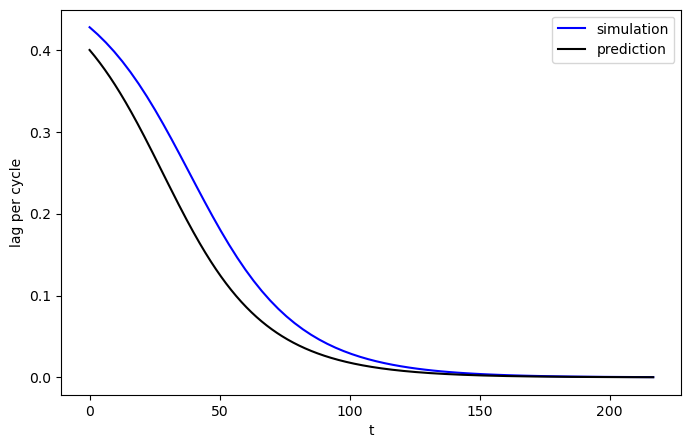

In [10]:
import numpy as np
import matplotlib.pyplot as plt

eps = 0.02

times = results[eps]["times"]
lags = results[eps]["lags"]

t_plot = np.linspace(0, times[-1], 1000)

prediction = (
    np.arctan(
        np.tan(np.pi * phi0)
        * np.exp(-2 * eps * t_plot)
    )
    / np.pi
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    times,
    lags,
    color="blue",
    label="simulation"
)

ax.plot(
    t_plot,
    prediction,
    color="black",
    label="prediction"
)

ax.set_xlabel("t")
ax.set_ylabel("lag per cycle")
ax.legend()

plt.show()

In [19]:
print("epsilon   fitted rate   2epsilon   difference")

for eps in [0.005, 0.02, 0.05]:
    times = results[eps]["times"]
    lags = results[eps]["lags"]

    mask = (lags > 0.01) & (lags < 0.25)

    t_fit = times[mask]
    y_fit = np.log(np.tan(np.pi * lags[mask]))

    slope, intercept = np.polyfit(t_fit, y_fit, 1)

    fitted_rate = -slope
    predicted_rate = 2 * eps

    error = (
        abs(fitted_rate - predicted_rate)
        / predicted_rate
        * 100
    )

    print(
        f"{eps:.4f}    "
        f"{fitted_rate:.4f}        "
        f"{predicted_rate:.4f}     "
        f"{error:.4f}"
    )

epsilon   fitted rate   2epsilon   difference
0.0050    0.0098        0.0100     2.2260
0.0200    0.0389        0.0400     2.7984
0.0500    0.0958        0.1000     4.1854
